In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

In [6]:
# loading your dataset into Python
# shape prints the number of rows and columns
df = pd.read_csv(r'C:\Users\User\Desktop\PORTFOLIO 2\BUSINESS\ Customer Churn Prediction\DATA\WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# TotalCharges has some empty strings — this converts them to NaN then drops them
df["TotalCharges"] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df = df.dropna()

# converts Churn from Yes/No text to 1/0 numbers the model can understand
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(df.shape)
df.dtypes

(7032, 20)


C:\Users\User\AppData\Local\Temp\ipykernel_3212\2667169602.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Churn"] = (df["Churn"] == "Yes").astype(int)


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [15]:
# most ML models can't read text like "Yes/No" or "Male/Female"
# LabelEncoder converts every text column to numbers automatically
le = LabelEncoder()

# loop through all columns — if a column contains text, convert it to numbers
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print("Encoding done")
df.head()

Encoding done


C:\Users\User\AppData\Local\Temp\ipykernel_3212\465299738.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
C:\Users\User\AppData\Local\Temp\ipykernel_3212\465299738.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
C:\Users\User\AppData\Local\Temp\ipykernel_3212\465299738.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [16]:
# X is everything except Churn — these are the clues the model learns from
# y is Churn — this is what the model is trying to predict
X = df.drop('Churn', axis=1)
y = df['Churn']

# balancing the dataset — creates artificial churned customer examples
# so the model sees equal numbers of churned and non-churned customers
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# scaling brings all numbers to the same range
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 8260
Testing rows: 2066


In [17]:
# --- Model 1: Logistic Regression (baseline) ---
# simple model that draws a line between churned and not churned
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, lr_preds))
print("AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]).round(3))

# --- Model 2: Random Forest ---
# builds hundreds of decision trees and combines their predictions
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("\nRandom Forest")
print(classification_report(y_test, rf_preds))
print("AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]).round(3))

Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1037
           1       0.79      0.84      0.81      1029

    accuracy                           0.81      2066
   macro avg       0.81      0.81      0.81      2066
weighted avg       0.81      0.81      0.81      2066

AUC: 0.888

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1037
           1       0.84      0.83      0.84      1029

    accuracy                           0.84      2066
   macro avg       0.84      0.84      0.84      2066
weighted avg       0.84      0.84      0.84      2066

AUC: 0.919


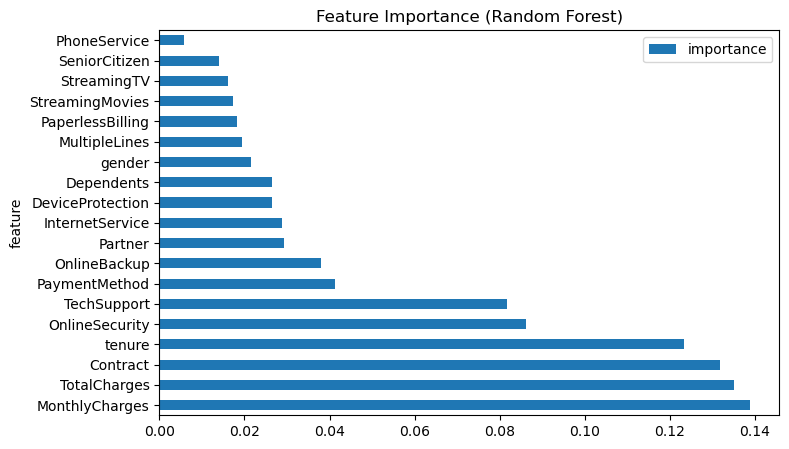

Files exported successfully


In [18]:
# shows which features the Random Forest relied on most
importance_df = pd.DataFrame({
    'feature': df.drop('Churn', axis=1).columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.plot(x='feature', y='importance', kind='barh', figsize=(8,5))
plt.title('Feature Importance (Random Forest)')
plt.show()

# exporting predictions with risk scores for Power BI
X_test_original = scaler.inverse_transform(X_test)
test_df = pd.DataFrame(X_test_original, columns=df.drop('Churn', axis=1).columns)
test_df['Actual_Churn'] = y_test.values
test_df['Predicted_Churn'] = rf_preds
test_df['Churn_Probability'] = rf.predict_proba(X_test)[:,1]

test_df.to_csv('churn_predictions.csv', index=False)
importance_df.to_csv('churn_feature_importance.csv', index=False)

print('Files exported successfully')

# Customer Churn Prediction — Project Summary

## Overview
Predicting which telecom customers are likely to leave using classification models.

**Dataset:** Telco Customer Churn — 7,043 customers with 20 features
**Tools:** Python, WPS Sheets, Power BI

## Data Cleaning
- Converted TotalCharges to numeric and dropped null rows
- Encoded all text columns to numbers using LabelEncoder
- Applied SMOTE to balance churned vs non-churned customers
- Final dataset after SMOTE: 10,326 rows

## WPS Sheets Findings
- Overall churn rate: 26.53%
- Month-to-month contracts have the highest churn at 2,220 customers
- Electronic check payment method has the highest churn rate at 45.3%

## Model Results

| Model | Accuracy | AUC |
|---|---|---|
| Logistic Regression | 81% | 0.888 |
| Random Forest | 84% | 0.919 |

## Key Findings
- Random Forest correctly predicts churn 84% of the time
- Contract type, TotalCharges and MonthlyCharges are the strongest predictors
- Pricing and commitment level are the biggest drivers of churn
- Customer behavior data is far more predictive than audio features in the Spotify project